In [ ]:
import pylab
from matplotlib import gridspec
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import numpy as np
from ipywidgets import interact, interactive, fixed
import ipywidgets as widgets
import pickle
import os
import gzip


In [2]:
np.random.seed(1)
import random

In [3]:
help(make_classification)

Help on function make_classification in module sklearn.datasets._samples_generator:

make_classification(n_samples=100, n_features=20, *, n_informative=2, n_redundant=2, n_repeated=0, n_classes=2, n_clusters_per_class=2, weights=None, flip_y=0.01, class_sep=1.0, hypercube=True, shift=0.0, scale=1.0, shuffle=True, random_state=None, return_X_y=True)
    Generate a random n-class classification problem.
    
    This initially creates clusters of points normally distributed (std=1)
    about vertices of an ``n_informative``-dimensional hypercube with sides of
    length ``2*class_sep`` and assigns an equal number of clusters to each
    class. It introduces interdependence between these features and adds
    various types of further noise to the data.
    
    Without shuffling, ``X`` horizontally stacks features in the following
    order: the primary ``n_informative`` features, followed by ``n_redundant``
    linear combinations of the informative features, followed by ``n_repeated``
 

In [ ]:
n = 50
X, Y = make_classification(
    n_samples = n,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    flip_y=0
)

Y = Y*2-1 
X = X.astype(np.float32); Y = Y.astype(np.int32) # Sparer minne

train_x, test_x, train_labels, test_labels = train_test_split(
    X, Y, test_size=0.2, random_state=1, stratify=Y
)

# Split the dataset into training and test
# train_x, test_x = np.split(X, [ n*8//10])
# train_labels, test_labels = np.split(Y, [n*8//10])

print("Features:\n",train_x[0:4])
print("Labels:\n",train_labels[0:4])

Features:
 [[-0.36825952 -1.9702464 ]
 [ 1.3660177   1.240567  ]
 [-1.1965445  -0.72856355]
 [-1.1518661   1.8413172 ]]
Labels:
 [-1  1 -1  1]


C:\Users\jsand\AppData\Local\Temp\ipykernel_14608\2456380072.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


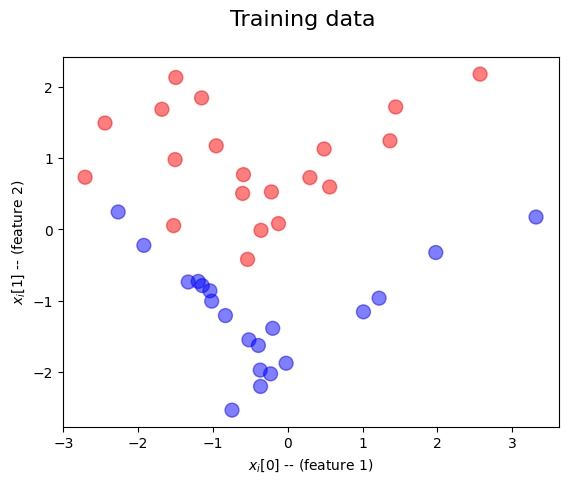

In [10]:
def plot_dataset(suptitle, features, labels):
    # prepare the plot
    fig, ax = pylab.subplots(1, 1)
    #pylab.subplots_adjust(bottom=0.2, wspace=0.4)
    fig.suptitle(suptitle, fontsize = 16)
    ax.set_xlabel('$x_i[0]$ -- (feature 1)')
    ax.set_ylabel('$x_i[1]$ -- (feature 2)')

    colors = ['r' if l>0 else 'b' for l in labels]
    ax.scatter(features[:, 0], features[:, 1], marker='o', c=colors, s=100, alpha = 0.5)
    fig.show()

plot_dataset('Training data', train_x, train_labels)

In [8]:
import numpy as np

unique, counts = np.unique(train_labels, return_counts=True)
print("Trening - klassefordeling:", dict(zip(unique, counts)))

unique, counts = np.unique(test_labels, return_counts=True)
print("Test - klassefordeling:", dict(zip(unique, counts)))

Trening - klassefordeling: {-1: 21, 1: 19}
Test - klassefordeling: {-1: 4, 1: 6}
